In [42]:
%pip install pandas numpy scikit-learn joblib seaborn statsmodels

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.8 kB 330.3 kB/s eta 0:00:01
     ----------------------------- -------- 41.0/52.8 kB 495.5 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 458.0 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     ------------- ------------------------- 41.0/119.8 kB 1.9 MB/s eta 0:00:01
     ----------------------------------- -- 112.6/119.8 kB 1.7 MB/s eta 0:00:01
     -------------------------------------- 119.8/119.8 kB 1.8 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/9.5 M

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import sklearn as sk
import joblib as job
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from pipeline import limpar_dados, criar_pre_processador

In [3]:
df = pd.read_csv('./datasets/treino.csv')
cols_to_drop = ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
df = limpar_dados(df, cols_to_drop)

In [21]:
#Análise exploratória dos dados
display(df.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,Reg,Lvl,AllPub,Inside,...,164,0,0,0,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,Reg,Lvl,AllPub,Corner,...,264,0,0,0,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Reg,Lvl,AllPub,Inside,...,242,0,0,0,0,5,2010,WD,Normal,127000


In [4]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1168 entries, 0 to 1167
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   str    
 3   LotFrontage    951 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   str    
 6   LotShape       1168 non-null   str    
 7   LandContour    1168 non-null   str    
 8   Utilities      1168 non-null   str    
 9   LotConfig      1168 non-null   str    
 10  LandSlope      1168 non-null   str    
 11  Neighborhood   1168 non-null   str    
 12  Condition1     1168 non-null   str    
 13  Condition2     1168 non-null   str    
 14  BldgType       1168 non-null   str    
 15  HouseStyle     1168 non-null   str    
 16  OverallQual    1168 non-null   int64  
 17  OverallCond    1168 non-null   int64  
 18  YearBuilt      1168

None

In [5]:
display(df.describe())

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1168.000000,1168.000000,951.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1162.000000,1168.000000,...,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000
mean,730.904966,56.849315,70.343849,10689.642123,6.121575,5.584760,1970.965753,1984.897260,103.771945,446.023973,...,95.946918,49.578767,21.839041,3.812500,15.407534,2.955479,51.267123,6.356164,2007.818493,181441.541952
std,425.369088,42.531862,24.897021,10759.366198,1.367619,1.116062,30.675495,20.733955,173.032238,459.070977,...,129.685939,69.433580,62.083227,31.519664,55.881148,41.648504,553.039684,2.670707,1.322639,77263.583862
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,360.750000,20.000000,59.000000,7587.250000,5.000000,5.000000,1953.000000,1966.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,130000.000000
50%,732.500000,50.000000,70.000000,9600.000000,6.000000,5.000000,1972.000000,1994.000000,0.000000,384.500000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,165000.000000
75%,1101.750000,70.000000,80.000000,11700.000000,7.000000,6.000000,2001.000000,2004.000000,166.000000,721.000000,...,168.000000,74.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214925.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1378.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,745000.000000


In [6]:
#Verificando a presença de dados nulos
nulos = df.isnull().sum()
print(nulos)

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      217
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 75, dtype: int64


# Possivel troca

In [ ]:
# Removendo os outliers de área gigante e preço baixo
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)

In [ ]:
# df_num = df.select_dtypes(include=['number'])
# df[df_num.columns] = df_num.fillna(df_num.median())

# # 3. Ajustar todas as CATEGÓRICAS (texto) de uma vez (usando a moda)
# # A moda é o valor que mais se repete na coluna
# df_cat = df.select_dtypes(include=['object'])
# for col in df_cat.columns:
#     df[col] = df[col].fillna(df[col].mode()[0])

# # Conferindo se ainda restou algum nulo
# print(f"Total de nulos no dataset: {df.isnull().sum().sum()}")

Total de nulos no dataset: 0


C:\Users\loren\AppData\Local\Temp\ipykernel_39588\452084097.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat = df.select_dtypes(include=['object'])


In [7]:
# 2. Separação de Features e Alvo
X = df.drop(columns=['SalePrice', 'Id'])
y = np.log1p(df['SalePrice']) # Aplica log para otimizar RMSLE [cite: 81]



# Perguntar se tem que ser aqui ou no pipeline.py
df['Idade_Casa'] = df['YrSold'] - df['YearBuilt']
df['Anos_Remodelacao'] = df['YrSold'] - df['YearRemodAdd']

In [8]:
# DEPOIS DA ANÁLISE DEBAIXO 
cols_to_drop_2 = ['MasVnrArea', 'BsmtFinSF2', 'BsmtUnfSF', 'LowQualFinSF', 'BsmtHalfBath', 'HalfBath', 'BedroomAbvGr','KitchenAbvGr','GarageYrBlt','GarageArea','OpenPorchSF','MiscVal','MoSold','YrSold']
df = limpar_dados(df, cols_to_drop_2)

In [14]:
cols_to_drop_3 = ['YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'FullBath','Anos_Remodelacao']
df = limpar_dados(df, cols_to_drop_3)

In [15]:
# 3. Definição das colunas por tipo
num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

C:\Users\loren\AppData\Local\Temp\ipykernel_24192\2891698516.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object']).columns


In [16]:
# # 4. Construção dos Transformers
# num_transformer = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler())
# ])
# cat_transformer = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='constant', fill_value='NA')),
#     ('onehot', OneHotEncoder(handle_unknown='ignore')) # Evita erros com novos dados [cite: 91]
# ])

# preprocessor = ColumnTransformer(transformers=[
#     ('num', num_transformer, num_features),
#     ('cat', cat_transformer, cat_features)
# ])

In [17]:
preprocessor = criar_pre_processador(num_features, cat_features)
X_transformado = preprocessor.fit_transform(X)


if hasattr(X_transformado, "toarray"):
    X_array = X_transformado.toarray()
else:
    X_array = X_transformado
    
# verificacao de nulos
total_nulos = np.isnan(X_array).sum()

print(f"Total de valores nulos após o preprocessor: {total_nulos}")

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])


Total de valores nulos após o preprocessor: 0


In [26]:
# # 5. Pipeline Final com Modelo
# # Usamos RandomForest como um modelo robusto superior ao Baseline [cite: 67]
# model_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
# ])

In [18]:
# 6. Treinamento
model_pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_ausencia', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

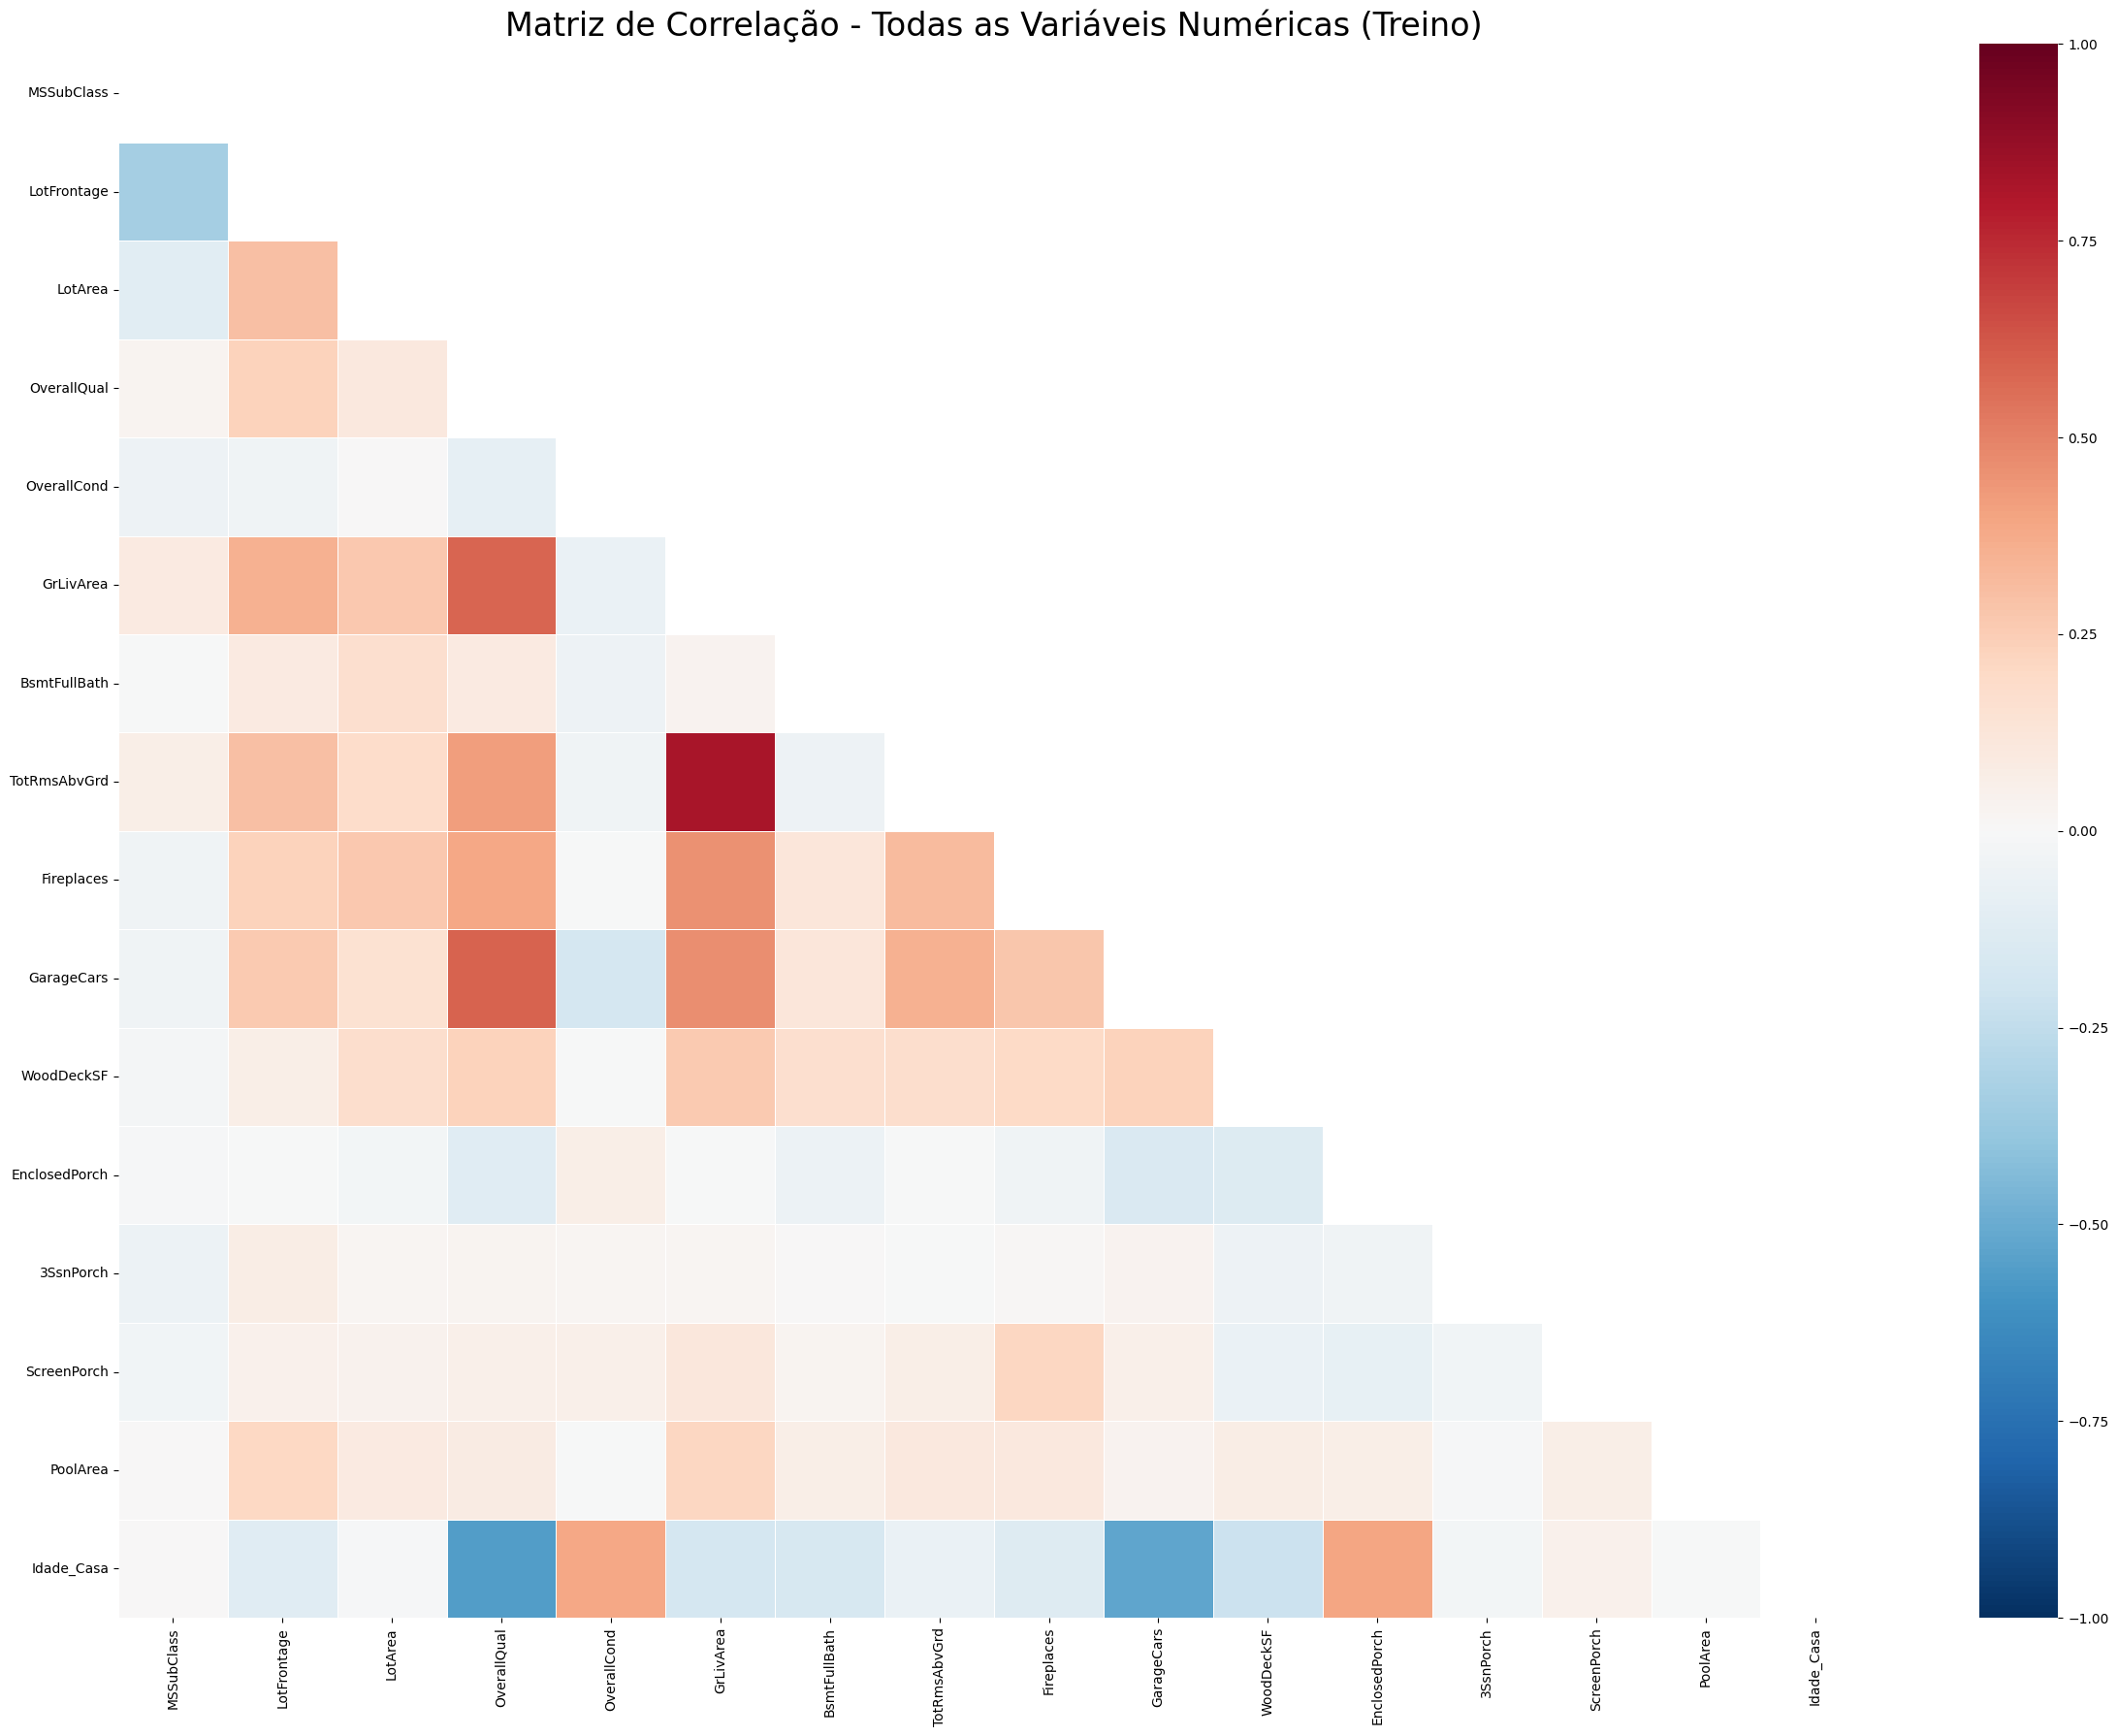

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolando apenas as variáveis numéricas e tratando nulos com a mediana (apenas para o gráfico)
X_numerico = df.select_dtypes(include=[np.number]).drop(columns=['Id', 'SalePrice'])
X_numerico = X_numerico.fillna(X_numerico.median())

# 2. Configurando o tamanho da figura (bem grande para caber as 36 variáveis)
plt.figure(figsize=(24, 18))

# 3. Calculando a matriz de correlação
corr = X_numerico.corr()

# 4. Criando uma máscara para esconder o triângulo superior (evita dados duplicados visualmente)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 5. Plotando o Heatmap
sns.heatmap(corr, mask=mask, cmap='RdBu_r', annot=False, vmin=-1, vmax=1, center=0, linewidths=0.5)

# Título e ajustes finais
plt.title('Matriz de Correlação - Todas as Variáveis Numéricas (Treino)', fontsize=24)
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 2. Separando a variável alvo (y) com a transformação logarítmica exigida pela métrica
y = np.log1p(df['SalePrice'])

# 3. Separando as features (X) - pegando apenas as numéricas e removendo Id e alvo
X_numerico = df.select_dtypes(include=[np.number]).drop(columns=['Id', 'SalePrice'])

# 4. Imputação rápida (substituindo NaNs pela mediana para o OLS não quebrar)
X_numerico = X_numerico.fillna(X_numerico.median())

# 5. Escalonamento dos dados (colocando tudo na mesma escala)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_numerico), columns=X_numerico.columns)

# 6. Adicionando a constante (o Statsmodels exige o intercepto explicitamente, diferente do Scikit-Learn)
X_scaled = sm.add_constant(X_scaled)

# 7. Treinando o modelo OLS (Mínimos Quadrados Ordinários)
modelo_estatistico = sm.OLS(y, X_scaled).fit()

# 8. Imprimindo o sumário estatístico completo!
print(modelo_estatistico.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     437.8
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        12:03:17   Log-Likelihood:                 584.70
No. Observations:                1168   AIC:                            -1135.
Df Residuals:                    1151   BIC:                            -1049.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            12.0307      0.004   2782.734

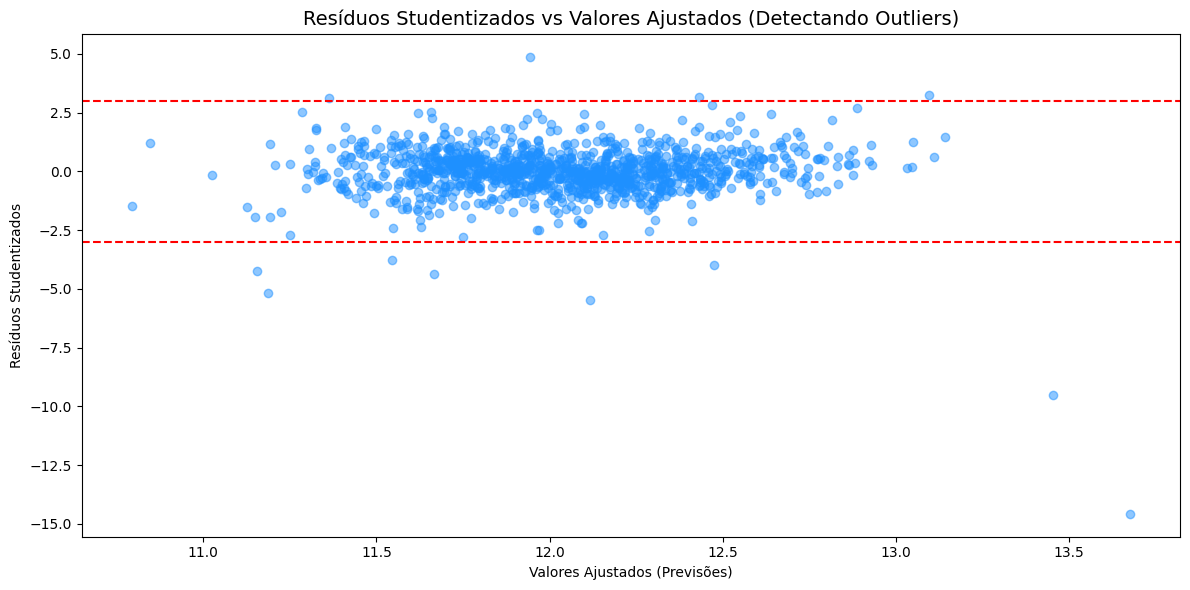

In [44]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. Definindo as variáveis (Alvo em Log e Preditores com inputação simples)
y = np.log1p(df['SalePrice'])
X_numerico = df.select_dtypes(include=[np.number]).drop(columns=['Id', 'SalePrice'])
X_numerico = X_numerico.fillna(X_numerico.median())

# 2. Escalonando os dados (importante para o statsmodels não dar erro matemático)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_numerico), columns=X_numerico.columns)

# 3. Adicionando a constante (o Statsmodels exige o intercepto explicitamente)
X_scaled = sm.add_constant(X_scaled)

# 4. Treinando o modelo OLS completo
modelo_completo = sm.OLS(y, X_scaled).fit()

# 5. Extraindo os resíduos studentizados
influence = modelo_completo.get_influence()
studentized_residuals = influence.resid_studentized_internal

# 6. Plotando o gráfico de dispersão
plt.figure(figsize=(12, 6))
plt.scatter(modelo_completo.fittedvalues, studentized_residuals, alpha=0.5, color='dodgerblue')

# Desenhando as linhas de alerta vermelho (Outliers Severos)
plt.axhline(y=3, color='r', linestyle='--')
plt.axhline(y=-3, color='r', linestyle='--')

# Textos do gráfico
plt.title('Resíduos Studentizados vs Valores Ajustados (Detectando Outliers)', fontsize=14)
plt.xlabel('Valores Ajustados (Previsões)')
plt.ylabel('Resíduos Studentizados')
plt.tight_layout()
plt.show()

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Criando o DataFrame para armazenar o VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_scaled.columns

# 2. Calculando o VIF de cada coluna
vif_data["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]

# 3. Limpando a coluna da 'constante' e ordenando para ver os maiores problemas primeiro
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False)

# 4. Mostrando as top 15 variáveis conflitantes
display(vif_data.head(15))

c:\Users\loren\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
6,YearBuilt,inf
13,1stFlrSF,inf
11,BsmtUnfSF,inf
10,BsmtFinSF2,inf
9,BsmtFinSF1,inf
7,YearRemodAdd,inf
16,GrLivArea,inf
37,Idade_Casa,inf
36,YrSold,inf
38,Anos_Remodelacao,inf
